# K-Fold Model Evaluation

Train MLP, DT, XGBOOST, and MGBDT with 5-fold cross-validation on the updated price CSV.

## Config

Use the updated processed data directory and explicitly named CSV file. Set feature-drop options and model hyperparameters here.

In [1]:
from pathlib import Path
import os
import sys
import random
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "house-price-regressor" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if PROJECT_ROOT.name != "house-price-regressor":
    raise RuntimeError("Run this notebook inside the house-price-regressor project.")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from metrics.adjusted_r2 import adjusted_r2
from metrics.mae import mae
from metrics.mape import mape
from metrics.mse import rmse
from metrics.r2_score import r2_score
from models import TrainConfig
from models.decision_tree import DecisionTree, DecisionTreeConfig
from models.mlp import MLP, MLPConfig
from models.mgbdt_ours import MGBDTModel, mGBDTConfig


def drop_addr(df: pd.DataFrame):
    return df.drop(columns=["city", "zipcode"])


def drop_coord(df: pd.DataFrame):
    return df.drop(columns=["x", "y", "z"])


def target_encode(train_X, train_y, test_X, col, smoothing=10):
    global_mean = train_y.mean()
    tmp = train_X[[col]].copy()
    tmp["_target"] = train_y.values
    stats = tmp.groupby(col)["_target"].agg(["mean", "count"])
    smooth = (stats["count"] * stats["mean"] + smoothing * global_mean) / (
        stats["count"] + smoothing
    )
    train_enc = train_X[col].map(smooth).fillna(global_mean)
    test_enc = test_X[col].map(smooth).fillna(global_mean)
    return train_enc, test_enc

# =========================
# Dataset / split settings
# =========================
DATA_CSV = PROJECT_ROOT / "data" / "processed" / "usa_housing_dataset_price.csv"
TARGET_NAME = "price"

DROP_ADDRESS = False
DROP_COORD = False

SEED = 42
N_SPLITS = 5
MODEL_ORDER = ["MLP", "DT", "XGBOOST", "MGBDT"]

OUTPUT_DIR = PROJECT_ROOT / "test" / "k-fold" / "folded"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Feature scaling settings
# =========================
MINMAX_COLS = [
    "x", "y", "z", "condition", "age", "bedrooms",
    "bathrooms", "floors", "view",
]

ZSCORE_COLS = [
    "sqft_living", "sqft_above", "sqft_basement",
    "log_sqft_lot", "city", "zipcode",
]

# =========================
# Model hyperparameters
# =========================
DT_HPARAMS = {
    "max_depth": 6,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
}

MLP_HPARAMS = {
    "hidden_dims": [32, 32],
    "dropout": 0.0,
    "use_batch_norm": True,
    "epochs": 50,
    "lr": 1e-2,
    "batch_size": 16,
}

# XGBOOST is implemented as MGBDTModel with one XGB layer, same as the other k-fold notebooks.
XGBOOST_SOURCE_HPARAMS = {
    "learning_rate": 0.1,
    "max_depth": 5,
    "num_boost_round": 5,
    "target_lr": 0.5,
    "epsilon": 0.3,
    "force_no_parallel": True,
    "epochs": 50,
    "batch_size": 16,
    "layer_configs": [("tp_layer", "xgb")],
}

XGBOOST_HPARAMS = dict(XGBOOST_SOURCE_HPARAMS)

# Best 2-layer candidate from experiments/mgbdt_hparam_markdown_results.md: epoch40_2L.
MGBDT_HPARAMS = {
    "learning_rate": 0.08,
    "max_depth": 4,
    "num_boost_round": 5,
    "target_lr": 0.5,
    "epsilon": 0.25,
    "force_no_parallel": True,
    "epochs": 40,
    "batch_size": 16,
    "layer_configs": [("tp_layer", "xgb"), ("tp_layer", "xgb")],
}

HPARAMS = {
    "MLP": MLP_HPARAMS,
    "DT": DT_HPARAMS,
    "XGBOOST": XGBOOST_HPARAMS,
    "MGBDT": MGBDT_HPARAMS,
}

CONFIG = {
    "project_root": str(PROJECT_ROOT),
    "data_csv": str(DATA_CSV),
    "target_name": TARGET_NAME,
    "drop_address": DROP_ADDRESS,
    "drop_coord": DROP_COORD,
    "seed": SEED,
    "n_splits": N_SPLITS,
    "model_order": MODEL_ORDER,
    "output_dir": str(OUTPUT_DIR.relative_to(PROJECT_ROOT)),
    "hparams": HPARAMS,
}

CONFIG


{'project_root': 'C:\\Career\\UNIST\\4-1\\Machine Learning\\Project\\house-price-regressor',
 'data_csv': 'C:\\Career\\UNIST\\4-1\\Machine Learning\\Project\\house-price-regressor\\data\\processed\\usa_housing_dataset_price.csv',
 'target_name': 'price',
 'drop_address': False,
 'drop_coord': False,
 'seed': 42,
 'n_splits': 5,
 'model_order': ['MLP', 'DT', 'XGBOOST', 'MGBDT'],
 'output_dir': 'test\\k-fold\\folded',
 'hparams': {'MLP': {'hidden_dims': [32, 32],
   'dropout': 0.0,
   'use_batch_norm': True,
   'epochs': 50,
   'lr': 0.01,
   'batch_size': 16},
  'DT': {'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 2},
  'XGBOOST': {'learning_rate': 0.1,
   'max_depth': 5,
   'num_boost_round': 5,
   'target_lr': 0.5,
   'epsilon': 0.3,
   'force_no_parallel': True,
   'epochs': 50,
   'batch_size': 16,
   'layer_configs': [('tp_layer', 'xgb')]},
  'MGBDT': {'learning_rate': 0.08,
   'max_depth': 4,
   'num_boost_round': 5,
   'target_lr': 0.5,
   'epsilon': 0.25,
   'force

## Training

Run 5-fold training in the fixed order: MLP, DT, XGBOOST, then MGBDT. Each fold saves one model file under `test/k-fold/folded`.

In [2]:
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def existing_cols(df: pd.DataFrame, cols: list[str]) -> list[str]:
    return [col for col in cols if col in df.columns]


def split_X_y(df: pd.DataFrame, target: str):
    X = df.drop(columns=[target])
    y = df[target]
    return X, y


def preprocess_fold(X_train, X_val, y_train_fit, model_name: str):
    X_train = X_train.copy()
    X_val = X_val.copy()

    for col in ["city", "zipcode"]:
        if col in X_train.columns:
            X_train[col], X_val[col] = target_encode(X_train, y_train_fit, X_val, col)

    mm_cols = existing_cols(X_train, MINMAX_COLS)
    if mm_cols:
        scaler_mm = MinMaxScaler()
        X_train[mm_cols] = scaler_mm.fit_transform(X_train[mm_cols])
        X_val[mm_cols] = scaler_mm.transform(X_val[mm_cols])

    z_cols = existing_cols(X_train, ZSCORE_COLS)
    if z_cols:
        scaler_z = StandardScaler()
        X_train[z_cols] = scaler_z.fit_transform(X_train[z_cols])
        X_val[z_cols] = scaler_z.transform(X_val[z_cols])

    if model_name == "DT" and "age" in X_train.columns:
        X_train["age_bin"] = pd.cut(X_train["age"], bins=5, labels=[0, 1, 2, 3, 4]).astype(float)
        X_val["age_bin"] = pd.cut(X_val["age"], bins=5, labels=[0, 1, 2, 3, 4]).astype(float)

    if DROP_ADDRESS:
        X_train = drop_addr(X_train)
        X_val = drop_addr(X_val)
    if DROP_COORD:
        X_train = drop_coord(X_train)
        X_val = drop_coord(X_val)

    return X_train, X_val


def build_model(model_name: str, input_dim: int):
    if model_name == "MLP":
        hp = MLP_HPARAMS
        return MLP(
            MLPConfig(
                model="mlp",
                input_dim=input_dim,
                hidden_dims=hp["hidden_dims"],
                output_dim=1,
                dropout=hp["dropout"],
                use_batch_norm=hp["use_batch_norm"],
            )
        )

    if model_name == "DT":
        return DecisionTree(DecisionTreeConfig(model="dt", **DT_HPARAMS))

    if model_name == "XGBOOST":
        hp = XGBOOST_HPARAMS
        cfg = mGBDTConfig(
            model="mgbdt",
            input_size=input_dim,
            output_size=1,
            task="regression",
            learning_rate=hp["learning_rate"],
            max_depth=hp["max_depth"],
            num_boost_round=hp["num_boost_round"],
            target_lr=hp["target_lr"],
            epsilon=hp["epsilon"],
            force_no_parallel=hp["force_no_parallel"],
        )
        return MGBDTModel(cfg, layer_configs=hp["layer_configs"])

    if model_name == "MGBDT":
        hp = MGBDT_HPARAMS
        cfg = mGBDTConfig(
            model="mgbdt",
            input_size=input_dim,
            output_size=1,
            task="regression",
            learning_rate=hp["learning_rate"],
            max_depth=hp["max_depth"],
            num_boost_round=hp["num_boost_round"],
            target_lr=hp["target_lr"],
            epsilon=hp["epsilon"],
            force_no_parallel=hp["force_no_parallel"],
        )
        return MGBDTModel(cfg, layer_configs=hp["layer_configs"])

    raise ValueError(f"Unknown model: {model_name}")


def fit_model(model_name: str, model, X_train, y_train_fit):
    if model_name == "MLP":
        hp = MLP_HPARAMS
        cfg = TrainConfig(X=X_train, y=y_train_fit, epochs=hp["epochs"], lr=hp["lr"], batch_size=hp["batch_size"], verbose=False)
        model.fit(cfg)
        return model

    if model_name == "DT":
        cfg = TrainConfig(X=X_train, y=y_train_fit, epochs=1, lr=0.0, batch_size=None, verbose=False)
        model.fit(cfg)
        return model

    if model_name == "XGBOOST":
        hp = XGBOOST_HPARAMS
        cfg = TrainConfig(X=X_train, y=y_train_fit, epochs=hp["epochs"], lr=hp["learning_rate"], batch_size=hp["batch_size"], verbose=False)
        model.fit(cfg)
        return model

    if model_name == "MGBDT":
        hp = MGBDT_HPARAMS
        cfg = TrainConfig(X=X_train, y=y_train_fit, epochs=hp["epochs"], lr=hp["learning_rate"], batch_size=hp["batch_size"], verbose=False)
        model.fit(cfg)
        return model

    raise ValueError(f"Unknown model: {model_name}")


def predict_model(model, X):
    return model.predict(X)


def model_settings_text(model_name: str, input_dim: int) -> str:
    compact = dict(HPARAMS[model_name])
    if model_name == "MGBDT":
        compact["layer_configs"] = str(compact["layer_configs"])
    compact["input_dim"] = input_dim
    return str(compact)


def metric_dict(y_true, y_pred, n_features: int):
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "R2": r2,
        "Adjusted_R2": adjusted_r2(y_true, y_pred, n_features),
    }


def save_model(model_name: str, fold: int, model):
    path = OUTPUT_DIR / f"{model_name}{fold}.pth"
    torch.save(model.state_dict(), path)
    return path


set_seed(SEED)
df = pd.read_csv(DATA_CSV)
X_all, y_all = split_X_y(df, TARGET_NAME)

print(f"DATA CSV: {DATA_CSV}")
print(f"TARGET: {TARGET_NAME}")
print(f"DROP_ADDRESS: {DROP_ADDRESS}")
print(f"DROP_COORD: {DROP_COORD}")
print(f"ROWS: {len(df)}")
print(f"RAW FEATURES: {X_all.shape[1]}")
print(f"MODEL ORDER: {MODEL_ORDER}")


DATA CSV: C:\Career\UNIST\4-1\Machine Learning\Project\house-price-regressor\data\processed\usa_housing_dataset_price.csv
TARGET: price
DROP_ADDRESS: False
DROP_COORD: False
ROWS: 4050
RAW FEATURES: 17
MODEL ORDER: ['MLP', 'DT', 'XGBOOST', 'MGBDT']


In [3]:
rows = []
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

for model_name in MODEL_ORDER:
    print(f"\n===== {model_name} 5-FOLD START =====")
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_all), start=1):
        set_seed(SEED + fold)

        X_train_raw = X_all.iloc[train_idx].copy()
        X_val_raw = X_all.iloc[val_idx].copy()
        y_train_raw = y_all.iloc[train_idx].copy()
        y_val_raw = y_all.iloc[val_idx].copy()

        target_scaler = MinMaxScaler()
        y_train_fit = pd.Series(
            target_scaler.fit_transform(y_train_raw.values.reshape(-1, 1)).ravel(),
            index=y_train_raw.index,
        )

        X_train, X_val = preprocess_fold(X_train_raw, X_val_raw, y_train_fit, model_name)
        input_dim = X_train.shape[1]
        model = build_model(model_name, input_dim)

        fit_start = time.perf_counter()
        model = fit_model(model_name, model, X_train, y_train_fit)
        fit_seconds = time.perf_counter() - fit_start

        pred_start = time.perf_counter()
        y_train_pred = predict_model(model, X_train)
        y_val_pred = predict_model(model, X_val)
        predict_seconds = time.perf_counter() - pred_start

        y_train_pred = target_scaler.inverse_transform(np.asarray(y_train_pred).reshape(-1, 1)).ravel()
        y_val_pred = target_scaler.inverse_transform(np.asarray(y_val_pred).reshape(-1, 1)).ravel()

        model_path = save_model(model_name, fold, model)
        settings = model_settings_text(model_name, input_dim)

        for split, y_true, y_pred in [
            ("train", y_train_raw, y_train_pred),
            ("val", y_val_raw, y_val_pred),
        ]:
            metrics = metric_dict(y_true, y_pred, input_dim)
            rows.append(
                {
                    "model": model_name,
                    "fold": fold,
                    "split": split,
                    "target": TARGET_NAME,
                    "data_csv": str(DATA_CSV.relative_to(PROJECT_ROOT)),
                    "drop_address": DROP_ADDRESS,
                    "drop_coord": DROP_COORD,
                    "n_features": input_dim,
                    "settings": settings,
                    "fit_seconds": fit_seconds,
                    "predict_seconds": predict_seconds,
                    "model_path": str(model_path.relative_to(PROJECT_ROOT)),
                    **metrics,
                }
            )

        print(
            f"{model_name}{fold}: FIT={fit_seconds:.3f}s, "
            f"VAL MAE={rows[-1]['MAE']:.4f}, VAL RMSE={rows[-1]['RMSE']:.4f}, "
            f"VAL R2={rows[-1]['R2']:.4f}, SAVED={model_path.name}"
        )

results_df = pd.DataFrame(rows)
metrics_path = OUTPUT_DIR / "maine_kfold_metrics.csv"
results_df.to_csv(metrics_path, index=False)

print("\nSAVED METRICS:", metrics_path)
print("SAVED MODEL FILES:", len(list(OUTPUT_DIR.glob("*.pth"))))



===== MLP 5-FOLD START =====
[MLP.fit] Execution time: 25.0942 sec
[MLP.predict] Execution time: 0.0021 sec
[MLP.predict] Execution time: 0.0009 sec
MLP1: FIT=25.095s, VAL MAE=99331.7922, VAL RMSE=139145.8569, VAL R2=0.7648, SAVED=MLP1.pth
[MLP.fit] Execution time: 21.5194 sec
[MLP.predict] Execution time: 0.0016 sec
[MLP.predict] Execution time: 0.0006 sec
MLP2: FIT=21.520s, VAL MAE=86396.1636, VAL RMSE=131372.7659, VAL R2=0.8184, SAVED=MLP2.pth
[MLP.fit] Execution time: 21.8327 sec
[MLP.predict] Execution time: 0.0015 sec
[MLP.predict] Execution time: 0.0006 sec
MLP3: FIT=21.833s, VAL MAE=90135.2552, VAL RMSE=148688.5417, VAL R2=0.7371, SAVED=MLP3.pth
[MLP.fit] Execution time: 21.6920 sec
[MLP.predict] Execution time: 0.0023 sec
[MLP.predict] Execution time: 0.0010 sec
MLP4: FIT=21.693s, VAL MAE=81668.4016, VAL RMSE=135637.0265, VAL R2=0.7691, SAVED=MLP4.pth
[MLP.fit] Execution time: 21.8408 sec
[MLP.predict] Execution time: 0.0017 sec
[MLP.predict] Execution time: 0.0007 sec
MLP5: 

C:\Users\hsh54\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)
C:\Users\hsh54\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [20:32:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[ 2026-06-06 20:32:29,279][mgbdt.log] [epoch=0/50][train] loss=0.080425


[DecisionTree.fit] Execution time: 0.0222 sec
[DecisionTree.predict] Execution time: 0.0019 sec
[DecisionTree.predict] Execution time: 0.0012 sec
DT4: FIT=0.023s, VAL MAE=101395.0251, VAL RMSE=156458.5131, VAL R2=0.6927, SAVED=DT4.pth
[DecisionTree.fit] Execution time: 0.0223 sec
[DecisionTree.predict] Execution time: 0.0017 sec
[DecisionTree.predict] Execution time: 0.0011 sec
DT5: FIT=0.022s, VAL MAE=107520.9212, VAL RMSE=169423.5697, VAL R2=0.6756, SAVED=DT5.pth

===== XGBOOST 5-FOLD START =====


[ 2026-06-06 20:32:29,314][mgbdt.log] [epoch=1/50][train] loss=0.031673
[ 2026-06-06 20:32:29,357][mgbdt.log] [epoch=2/50][train] loss=0.013913
[ 2026-06-06 20:32:29,386][mgbdt.log] [epoch=3/50][train] loss=0.007252
[ 2026-06-06 20:32:29,417][mgbdt.log] [epoch=4/50][train] loss=0.004603
[ 2026-06-06 20:32:29,447][mgbdt.log] [epoch=5/50][train] loss=0.003449
[ 2026-06-06 20:32:29,476][mgbdt.log] [epoch=6/50][train] loss=0.002892
[ 2026-06-06 20:32:29,509][mgbdt.log] [epoch=7/50][train] loss=0.002566
[ 2026-06-06 20:32:29,548][mgbdt.log] [epoch=8/50][train] loss=0.002360
[ 2026-06-06 20:32:29,590][mgbdt.log] [epoch=9/50][train] loss=0.002212
[ 2026-06-06 20:32:29,635][mgbdt.log] [epoch=10/50][train] loss=0.002100
[ 2026-06-06 20:32:29,688][mgbdt.log] [epoch=11/50][train] loss=0.002000
[ 2026-06-06 20:32:29,745][mgbdt.log] [epoch=12/50][train] loss=0.001901
[ 2026-06-06 20:32:29,798][mgbdt.log] [epoch=13/50][train] loss=0.001799
[ 2026-06-06 20:32:29,858][mgbdt.log] [epoch=14/50][train] l

[MGBDTModel.fit] Execution time: 3.3827 sec
[MGBDTModel.predict] Execution time: 0.0109 sec
[MGBDTModel.predict] Execution time: 0.0063 sec
XGBOOST1: FIT=3.383s, VAL MAE=76759.6492, VAL RMSE=128092.8751, VAL R2=0.8007, SAVED=XGBOOST1.pth


...

[MGBDTModel.fit] Execution time: 5.2163 sec
[MGBDTModel.predict] Execution time: 0.0165 sec
[MGBDTModel.predict] Execution time: 0.0112 sec
MGBDT3: FIT=5.217s, VAL MAE=155654.7696, VAL RMSE=239042.3235, VAL R2=0.3204, SAVED=MGBDT3.pth


[ 2026-06-06 20:33:01,565][mgbdt.log] [epoch=1/40][train] loss=0.046498
[ 2026-06-06 20:33:01,639][mgbdt.log] [epoch=2/40][train] loss=0.028859
[ 2026-06-06 20:33:01,717][mgbdt.log] [epoch=3/40][train] loss=0.018798
[ 2026-06-06 20:33:01,788][mgbdt.log] [epoch=4/40][train] loss=0.010880
[ 2026-06-06 20:33:01,868][mgbdt.log] [epoch=5/40][train] loss=0.008947
[ 2026-06-06 20:33:01,949][mgbdt.log] [epoch=6/40][train] loss=0.008124
C:\Users\hsh54\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [20:33:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[ 2026-06-06 20:33:02,044][mgbdt.log] [epoch=7/40][train] loss=0.007386
[ 2026-06-06 20:33:02,140][mgbdt.log] [epoch=8/40][train] loss=0.006857
[ 2026-06-06 20:33:02,245][mgbdt.log] [epoch=9/40][train] loss=0.006332
[ 2026-06-06 20:33:02,341][mgbdt.log] [epoch=10/40][train] loss=0.005915
[ 2026-06-06 2

[MGBDTModel.fit] Execution time: 5.2619 sec
[MGBDTModel.predict] Execution time: 0.0129 sec
[MGBDTModel.predict] Execution time: 0.0077 sec
MGBDT4: FIT=5.262s, VAL MAE=94576.9711, VAL RMSE=158380.1830, VAL R2=0.6851, SAVED=MGBDT4.pth


[ 2026-06-06 20:33:06,985][mgbdt.log] [epoch=2/40][train] loss=0.027795
C:\Users\hsh54\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [20:33:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[ 2026-06-06 20:33:07,056][mgbdt.log] [epoch=3/40][train] loss=0.024944
[ 2026-06-06 20:33:07,136][mgbdt.log] [epoch=4/40][train] loss=0.020796
[ 2026-06-06 20:33:07,217][mgbdt.log] [epoch=5/40][train] loss=0.017689
[ 2026-06-06 20:33:07,299][mgbdt.log] [epoch=6/40][train] loss=0.014019
[ 2026-06-06 20:33:07,387][mgbdt.log] [epoch=7/40][train] loss=0.012120
[ 2026-06-06 20:33:07,471][mgbdt.log] [epoch=8/40][train] loss=0.010196
[ 2026-06-06 20:33:07,560][mgbdt.log] [epoch=9/40][train] loss=0.009031
[ 2026-06-06 20:33:07,700][mgbdt.log] [epoch=10/40][train] loss=0.008419
[ 2026-06-06 20:33:07,810][mgbdt.log] [epoch=11/40][train] loss=0.007800
[ 2026-06-06 

[MGBDTModel.fit] Execution time: 5.3379 sec
[MGBDTModel.predict] Execution time: 0.0153 sec
[MGBDTModel.predict] Execution time: 0.0087 sec
MGBDT5: FIT=5.338s, VAL MAE=112844.9563, VAL RMSE=168307.7397, VAL R2=0.6799, SAVED=MGBDT5.pth

SAVED METRICS: C:\Career\UNIST\4-1\Machine Learning\Project\house-price-regressor\test\k-fold\folded\maine_kfold_metrics.csv
SAVED MODEL FILES: 25


## Evaluation

Display fold-level settings, fit time, and validation metrics for each model. Then summarize time and metric stability with mean and standard deviation.

In [4]:
def print_context(block_name: str):
    print(f"[{block_name.upper()}]")
    print(f"DATA CSV: {DATA_CSV}")
    print(f"TARGET: {TARGET_NAME}")
    print(f"DROP_ADDRESS: {DROP_ADDRESS}")
    print(f"DROP_COORD: {DROP_COORD}")
    print(f"FOLDS: {N_SPLITS}")
    print(f"MODEL ORDER: {MODEL_ORDER}")
    print()


display_cols = [
    "model", "fold", "target", "data_csv", "drop_address", "drop_coord", "n_features",
    "settings", "fit_seconds", "predict_seconds", "MAE", "RMSE", "MAPE",
    "R2", "Adjusted_R2", "model_path",
]

val_report = (
    results_df[results_df["split"].eq("val")]
    .copy()
    .sort_values(["model", "fold"], key=lambda s: s.map({m: i for i, m in enumerate(MODEL_ORDER)}) if s.name == "model" else s)
)

print_context("FOLD-LEVEL VALIDATION TABLE")
val_report[display_cols]


[FOLD-LEVEL VALIDATION TABLE]
DATA CSV: C:\Career\UNIST\4-1\Machine Learning\Project\house-price-regressor\data\processed\usa_housing_dataset_price.csv
TARGET: price
DROP_ADDRESS: False
DROP_COORD: False
FOLDS: 5
MODEL ORDER: ['MLP', 'DT', 'XGBOOST', 'MGBDT']



,model,fold,target,data_csv,drop_address,drop_coord,n_features,settings,fit_seconds,predict_seconds,MAE,RMSE,MAPE,R2,Adjusted_R2,model_path
1,MLP,1,price,data\processed\usa_housing_dataset_price.csv,False,False,17,"{'hidden_dims': [32, 32], 'dropout': 0.0, 'use...",25.094996,0.003080,99331.792186,139145.856876,26.117620,0.764847,0.759800,test\k-fold\folded\MLP1.pth
3,MLP,2,price,data\processed\usa_housing_dataset_price.csv,False,False,17,"{'hidden_dims': [32, 32], 'dropout': 0.0, 'use...",21.520070,0.002309,86396.163603,131372.765914,19.308376,0.818436,0.814539,test\k-fold\folded\MLP2.pth
5,MLP,3,price,data\processed\usa_housing_dataset_price.csv,False,False,17,"{'hidden_dims': [32, 32], 'dropout': 0.0, 'use...",21.833398,0.002223,90135.255184,148688.541738,18.220105,0.737055,0.731411,test\k-fold\folded\MLP3.pth
7,MLP,4,price,data\processed\usa_housing_dataset_price.csv,False,False,17,"{'hidden_dims': [32, 32], 'dropout': 0.0, 'use...",21.692714,0.003460,81668.401635,135637.026503,17.168020,0.769053,0.764096,test\k-fold\folded\MLP4.pth
9,MLP,5,price,data\processed\usa_housing_dataset_price.csv,False,False,17,"{'hidden_dims': [32, 32], 'dropout': 0.0, 'use...",21.841532,0.002494,90062.459018,142830.701217,19.053389,0.769458,0.764509,test\k-fold\folded\MLP5.pth
11,DT,1,price,data\processed\usa_housing_dataset_price.csv,False,False,18,"{'max_depth': 6, 'min_samples_split': 2, 'min_...",0.026046,0.004661,96027.608495,151528.456415,21.159388,0.721133,0.714787,test\k-fold\folded\DT1.pth
13,DT,2,price,data\processed\usa_housing_dataset_price.csv,False,False,18,"{'max_depth': 6, 'min_samples_split': 2, 'min_...",0.025023,0.003697,105672.787374,168645.488114,23.614219,0.700795,0.693987,test\k-fold\folded\DT2.pth
15,DT,3,price,data\processed\usa_housing_dataset_price.csv,False,False,18,"{'max_depth': 6, 'min_samples_split': 2, 'min_...",0.024432,0.003399,101659.047193,163919.896678,20.614958,0.680424,0.673152,test\k-fold\folded\DT3.pth
17,DT,4,price,data\processed\usa_housing_dataset_price.csv,False,False,18,"{'max_depth': 6, 'min_samples_split': 2, 'min_...",0.022963,0.003145,101395.025077,156458.513068,20.665178,0.692706,0.685714,test\k-fold\folded\DT4.pth
19,DT,5,price,data\processed\usa_housing_dataset_price.csv,False,False,18,"{'max_depth': 6, 'min_samples_split': 2, 'min_...",0.022341,0.002942,107520.921158,169423.569701,21.086808,0.675619,0.668237,test\k-fold\folded\DT5.pth


[TIME SUMMARY TABLE AND GRAPH]
DATA CSV: C:\Career\UNIST\4-1\Machine Learning\Project\house-price-regressor\data\processed\usa_housing_dataset_price.csv
TARGET: price
DROP_ADDRESS: False
DROP_COORD: False
FOLDS: 5
MODEL ORDER: ['MLP', 'DT', 'XGBOOST', 'MGBDT']



fit_seconds           predict_seconds          
               mean       std            mean       std
model                                                  
MLP       22.396542  1.514133        0.002713  0.000535
DT         0.024161  0.001510        0.003569  0.000673
XGBOOST    3.171184  0.124433        0.018031  0.002376
MGBDT      5.255903  0.120192        0.024138  0.002973

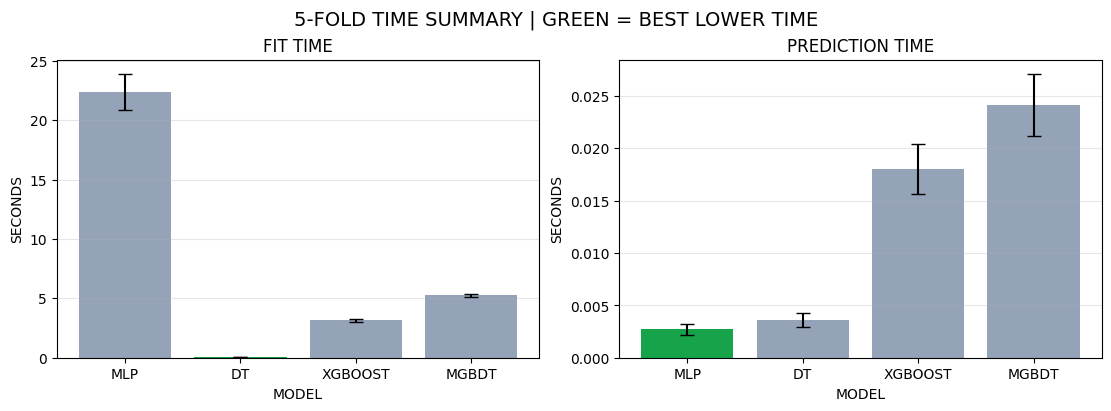

In [5]:
print_context("TIME SUMMARY TABLE AND GRAPH")

def winner_colors(stats, higher_is_better=False):
    best_model = stats["mean"].idxmax() if higher_is_better else stats["mean"].idxmin()
    return ["#16a34a" if model == best_model else "#94a3b8" for model in stats.index]


time_summary = (
    val_report.groupby("model")[["fit_seconds", "predict_seconds"]]
    .agg(["mean", "std"])
    .reindex(MODEL_ORDER)
)

display(time_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, col, title in [
    (axes[0], "fit_seconds", "FIT TIME"),
    (axes[1], "predict_seconds", "PREDICTION TIME"),
]:
    stats = val_report.groupby("model")[col].agg(["mean", "std"]).reindex(MODEL_ORDER)
    colors = winner_colors(stats, higher_is_better=False)
    ax.bar(stats.index, stats["mean"], yerr=stats["std"], capsize=5, color=colors)
    ax.set_title(title)
    ax.set_xlabel("MODEL")
    ax.set_ylabel("SECONDS")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("5-FOLD TIME SUMMARY | GREEN = BEST LOWER TIME", fontsize=14)
plt.show()


[METRIC SUMMARY TABLE AND GRAPH]
DATA CSV: C:\Career\UNIST\4-1\Machine Learning\Project\house-price-regressor\data\processed\usa_housing_dataset_price.csv
TARGET: price
DROP_ADDRESS: False
DROP_COORD: False
FOLDS: 5
MODEL ORDER: ['MLP', 'DT', 'XGBOOST', 'MGBDT']



MAE                         RMSE                     MAPE  \
                  mean           std           mean           std       mean   
model                                                                          
MLP       89518.814325   6487.488156  139534.978450   6644.860192  19.973502   
DT       102455.077860   4446.520044  161995.184795   7799.344350  21.428110   
XGBOOST   80378.571138   2831.315245  134806.886650   6854.146342  16.976774   
MGBDT    120584.023856  24127.952793  188868.243114  34774.473156  26.017731   

                         R2           Adjusted_R2            
              std      mean       std        mean       std  
model                                                        
MLP      3.534980  0.771770  0.029341    0.766871  0.029971  
DT       1.246099  0.694136  0.018070    0.687175  0.018481  
XGBOOST  1.090222  0.787476  0.023298    0.782914  0.023798  
MGBDT    6.337227  0.575140  0.155860    0.566021  0.159205

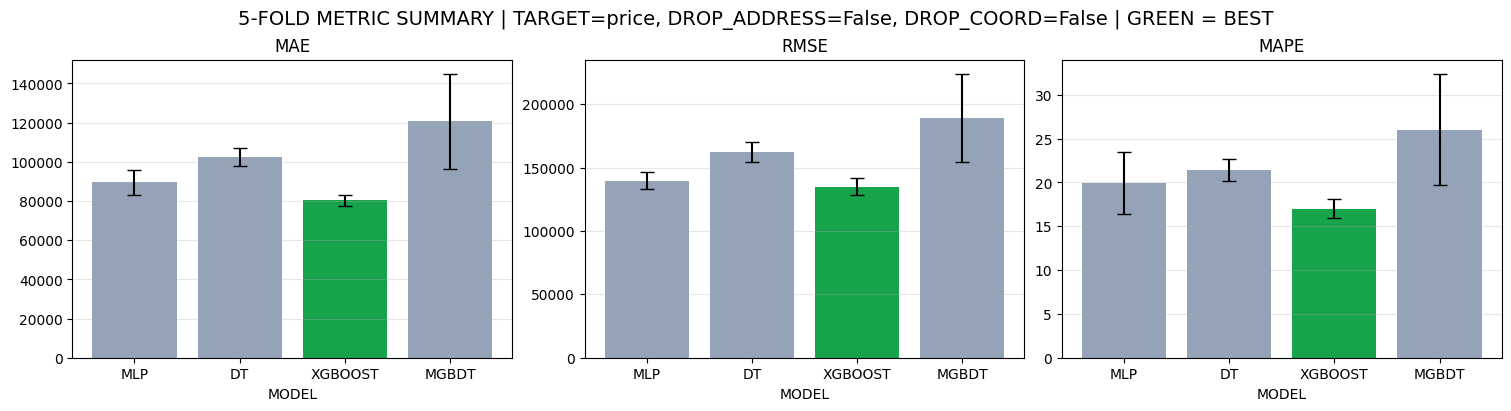

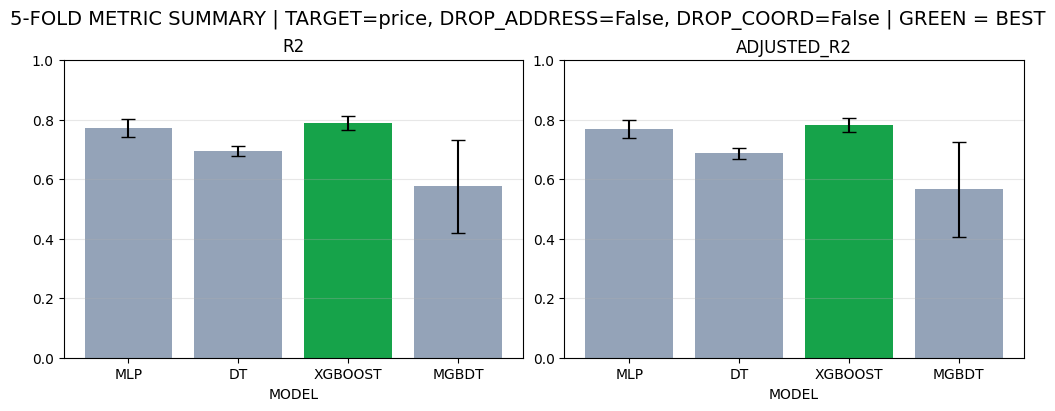

In [6]:
print_context("METRIC SUMMARY TABLE AND GRAPH")

def winner_colors(stats, higher_is_better):
    best_model = stats["mean"].idxmax() if higher_is_better else stats["mean"].idxmin()
    return ["#16a34a" if model == best_model else "#94a3b8" for model in stats.index]


metric_order = ["MAE", "RMSE", "MAPE", "R2", "Adjusted_R2"]
higher_is_better = {
    "MAE": False,
    "RMSE": False,
    "MAPE": False,
    "R2": True,
    "Adjusted_R2": True,
}

metric_summary = (
    val_report.groupby("model")[metric_order]
    .agg(["mean", "std"])
    .reindex(MODEL_ORDER)
)

display(metric_summary)

metric_groups = [
    ["MAE", "RMSE", "MAPE"],
    ["R2", "Adjusted_R2"],
]

for group in metric_groups:
    fig, axes = plt.subplots(1, len(group), figsize=(5 * len(group), 4), constrained_layout=True)
    if len(group) == 1:
        axes = [axes]
    for ax, metric in zip(axes, group):
        stats = val_report.groupby("model")[metric].agg(["mean", "std"]).reindex(MODEL_ORDER)
        colors = winner_colors(stats, higher_is_better=higher_is_better[metric])
        ax.bar(stats.index, stats["mean"], yerr=stats["std"], capsize=5, color=colors)
        ax.set_title(metric.upper())
        ax.set_xlabel("MODEL")
        ax.grid(axis="y", alpha=0.3)
        if metric in {"R2", "Adjusted_R2"}:
            low = min(0, float((stats["mean"].fillna(0)).min()) - 0.05)
            ax.set_ylim(low, 1.0)

    fig.suptitle(
        f"5-FOLD METRIC SUMMARY | TARGET={TARGET_NAME}, "
        f"DROP_ADDRESS={DROP_ADDRESS}, DROP_COORD={DROP_COORD} | GREEN = BEST",
        fontsize=14,
    )
    plt.show()
